In [2]:
# Task 1: Data Understanding & Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_csv('Students Social Media Addiction (1).csv')

# 1. Dataset Dimensions
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 2. First 5 Rows
print("\n--- First 5 Rows ---")
print(df.head())

# 3. Data Info & Data Types
print("\n--- Dataset Info ---")
print(df.info())

# 4. Summary Statistics
print("\n--- Summary Statistics ---")
print(df.describe())



--- Dataset Shape ---
Rows: 705, Columns: 13

--- First 5 Rows ---
   Student_ID  Age  Gender Academic_Level     Country  Avg_Daily_Usage_Hours  \
0           1   19  Female  Undergraduate  Bangladesh                    5.2   
1           2   22    Male       Graduate       India                    2.1   
2           3   20  Female  Undergraduate         USA                    6.0   
3           4   18    Male    High School          UK                    3.0   
4           5   21    Male       Graduate      Canada                    4.5   

  Most_Used_Platform Affects_Academic_Performance  Sleep_Hours_Per_Night  \
0          Instagram                          Yes                    6.5   
1            Twitter                           No                    7.5   
2             TikTok                          Yes                    5.0   
3            YouTube                           No                    7.0   
4           Facebook                          Yes                    6.0

In [4]:
# Task 2: Data Cleaning

# Check for missing values
print("--- Missing Values Check ---")
print(df.isnull().sum())

# Drop missing values if present
df = df.dropna()

# Perform data type conversions
df['Age'] = df['Age'].astype(int)
df['Avg_Daily_Usage_Hours'] = df['Avg_Daily_Usage_Hours'].astype(float)
df['Sleep_Hours_Per_Night'] = df['Sleep_Hours_Per_Night'].astype(float)
df['Mental_Health_Score'] = df['Mental_Health_Score'].astype(int)
df['Conflicts_Over_Social_Media'] = df['Conflicts_Over_Social_Media'].astype(int)
df['Addicted_Score'] = df['Addicted_Score'].astype(int)

print("\nData cleaning and type conversions completed successfully.")


--- Missing Values Check ---
Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

Data cleaning and type conversions completed successfully.


In [5]:
# Task 3: Functions, Loops & Feature Engineering

# Function 1: Classify Risk Level based on daily usage hours
def classify_risk(hours):
    if hours < 3.0:
        return 'Low Risk'
    elif 3.0 <= hours <= 6.0:
        return 'Medium Risk'
    else:
        return 'High Risk'

# Function 2: Suggest Digital Detox Strategy using if-else logic
def detox_strategy(risk_level):
    if risk_level == 'Low Risk':
        return 'Maintain healthy habits; practice 30-min screen-free time before bed.'
    elif risk_level == 'Medium Risk':
        return 'Set daily app time limits (max 2 hrs); turn off non-essential push notifications.'
    else:
        return 'Enforce app lock timers, schedule weekend screen-free detoxes, seek counseling support.'

# Apply custom functions to create new features
df['Risk_Level'] = df['Avg_Daily_Usage_Hours'].apply(classify_risk)
df['Detox_Strategy'] = df['Risk_Level'].apply(detox_strategy)

# Bin Age into Age Groups
df['Age_Group'] = pd.cut(df['Age'], bins=[14, 18, 22, 30], labels=['15-18', '19-22', '23+'])

# View engineered features
df[['Student_ID', 'Avg_Daily_Usage_Hours', 'Risk_Level', 'Detox_Strategy']].head()

,Student_ID,Avg_Daily_Usage_Hours,Risk_Level,Detox_Strategy
0,1,5.2,Medium Risk,Set daily app time limits (max 2 hrs); turn of...
1,2,2.1,Low Risk,Maintain healthy habits; practice 30-min scree...
2,3,6.0,Medium Risk,Set daily app time limits (max 2 hrs); turn of...
3,4,3.0,Medium Risk,Set daily app time limits (max 2 hrs); turn of...
4,5,4.5,Medium Risk,Set daily app time limits (max 2 hrs); turn of...


In [6]:
# Task 4: Grouping & Aggregation Insights

print("=== DEMOGRAPHIC AGGREGATION ANALYSIS ===")

# 1. Aggregation by Gender
print("\n--- Average Addiction & Usage by Gender ---")
gender_summary = df.groupby('Gender')[['Addicted_Score', 'Avg_Daily_Usage_Hours']].mean().round(2)
print(gender_summary)

# 2. Aggregation by Age Group
print("\n--- Average Addiction & Usage by Age Group ---")
age_summary = df.groupby('Age_Group', observed=False)[['Addicted_Score', 'Avg_Daily_Usage_Hours']].mean().round(2)
print(age_summary)

# 3. Aggregation by Academic Level
print("\n--- Average Addiction & Usage by Academic Level ---")
academic_summary = df.groupby('Academic_Level')[['Addicted_Score', 'Avg_Daily_Usage_Hours']].mean().round(2)
print(academic_summary)




=== DEMOGRAPHIC AGGREGATION ANALYSIS ===

--- Average Addiction & Usage by Gender ---
        Addicted_Score  Avg_Daily_Usage_Hours
Gender                                       
Female            6.52                   5.01
Male              6.36                   4.83

--- Average Addiction & Usage by Age Group ---
           Addicted_Score  Avg_Daily_Usage_Hours
Age_Group                                       
15-18                7.79                   5.39
19-22                6.46                   4.93
23+                  5.87                   4.74

--- Average Addiction & Usage by Academic Level ---
                Addicted_Score  Avg_Daily_Usage_Hours
Academic_Level                                       
Graduate                  6.24                   4.78
High School               8.04                   5.54
Undergraduate             6.49                   5.00


In [8]:
# Task 5: Data Visualization & Insights

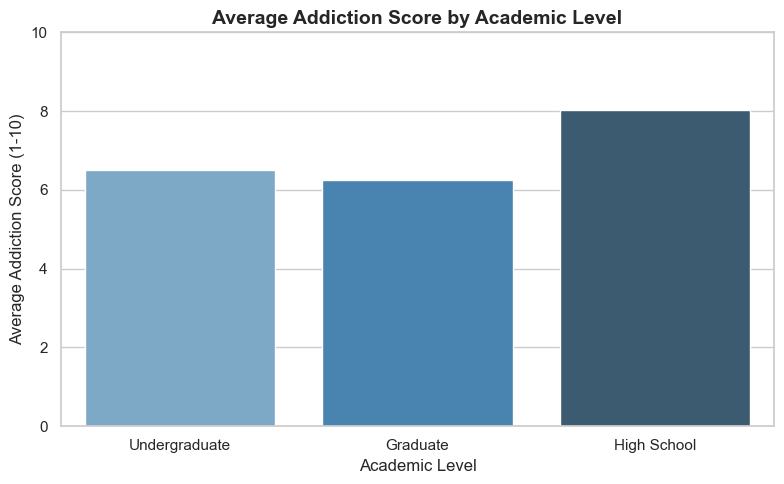

Insight: High School students demonstrate the highest mean addiction score (~8.04), indicating that younger students are the most vulnerable group requiring targeted digital wellness interventions.


In [12]:
# Chart 1: Bar Chart (Addiction by Academic Level)

plt.figure(figsize=(8, 5))

# Updated syntax to prevent Seaborn deprecation warnings
sns.barplot(
    data=df, 
    x='Academic_Level', 
    y='Addicted_Score', 
    hue='Academic_Level', 
    palette='Blues_d', 
    legend=False, 
    errorbar=None
)

plt.title('Average Addiction Score by Academic Level', fontsize=14, fontweight='bold')
plt.xlabel('Academic Level', fontsize=12)
plt.ylabel('Average Addiction Score (1-10)', fontsize=12)
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

print("Insight: High School students demonstrate the highest mean addiction score (~8.04), indicating that younger students are the most vulnerable group requiring targeted digital wellness interventions.")

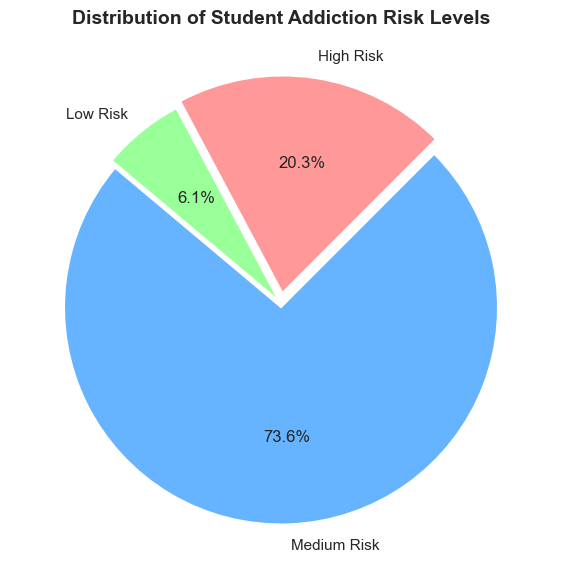

Insight: Over 20% of surveyed students fall into the High-Risk category (>6 hrs/day), while nearly 74% are at Medium Risk, proving that excessive usage is a widespread campus issue.


In [13]:
# Chart 2: Pie Chart (Risk Level Distribution)

plt.figure(figsize=(6, 6))
risk_counts = df['Risk_Level'].value_counts()
colors = ['#66b3ff', '#ff9999', '#99ff99']
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', colors=colors, startangle=140, explode=(0.02, 0.05, 0.02))
plt.title('Distribution of Student Addiction Risk Levels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight: Over 20% of surveyed students fall into the High-Risk category (>6 hrs/day), while nearly 74% are at Medium Risk, proving that excessive usage is a widespread campus issue.")

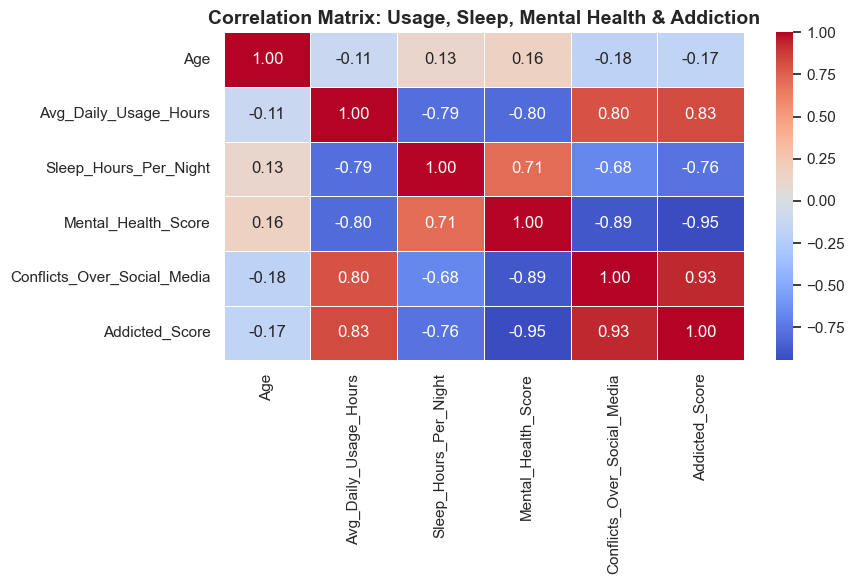

Insight: Daily usage hours show a strong positive correlation with Addiction (+0.83) and Conflicts (+0.80), alongside a severe negative correlation with Mental Health (-0.80) and Sleep (-0.79).


In [14]:
# Chart 3: Correlation Heatmap

plt.figure(figsize=(9, 6))
numeric_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Usage, Sleep, Mental Health & Addiction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight: Daily usage hours show a strong positive correlation with Addiction (+0.83) and Conflicts (+0.80), alongside a severe negative correlation with Mental Health (-0.80) and Sleep (-0.79).")


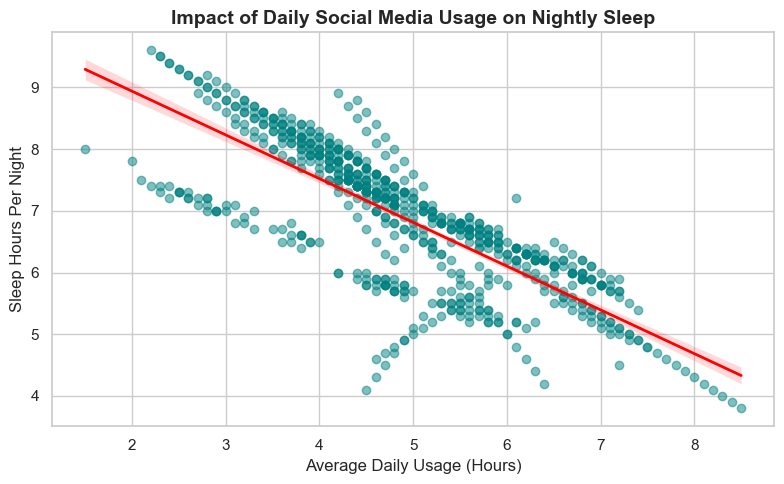

Insight: As daily social media screen time increases past 5 hours, nightly sleep duration drops precipitously, directly linking high addiction levels with sleep deprivation.


In [15]:
# Chart 4: Regression Plot (Usage vs. Sleep Hours)

plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Avg_Daily_Usage_Hours', y='Sleep_Hours_Per_Night', color='teal', scatter_kws={'alpha':0.5}, line_kws={'color':'red', 'linewidth':2})
plt.title('Impact of Daily Social Media Usage on Nightly Sleep', fontsize=14, fontweight='bold')
plt.xlabel('Average Daily Usage (Hours)', fontsize=12)
plt.ylabel('Sleep Hours Per Night', fontsize=12)
plt.tight_layout()
plt.show()

print("Insight: As daily social media screen time increases past 5 hours, nightly sleep duration drops precipitously, directly linking high addiction levels with sleep deprivation.")

In [16]:
# Task 6: Storytelling Deliverable

story_summary = """
=== STORYTELLING SUMMARY: COMBATING STUDENT SOCIAL MEDIA ADDICTION ===

1. Analysis of 705 student records reveals an average daily screen time of 4.92 hours, leading to significant digital dependency.
2. Younger students are the most impacted, with High Schoolers exhibiting the highest average addiction score of 8.04 out of 10.
3. Demographic analysis shows a steady decrease in social media addiction as age and academic level advance.
4. Over 20% of all surveyed students exceed 6 hours of daily usage, placing them in the critical High-Risk category.
5. Statistical correlation demonstrates that increased daily screen time strongly drives higher social media conflicts (+0.80 correlation).
6. Nightly sleep hours drop sharply as screen time increases (-0.79 correlation), causing widespread sleep deprivation.
7. A steep decline in self-reported mental health scores (-0.80 correlation) highlights the emotional toll of unchecked usage.
8. Platform engagement and late-night scrolling are key root causes driving academic disruption across institutions.
9. Institutional solutions must combine automated app daily limits with mandatory screen-free study zones.
10. Early intervention for High School and Undergraduate students is essential to restore focus, sleep hygiene, and mental wellness.
"""

print(story_summary)


=== STORYTELLING SUMMARY: COMBATING STUDENT SOCIAL MEDIA ADDICTION ===

1. Analysis of 705 student records reveals an average daily screen time of 4.92 hours, leading to significant digital dependency.
2. Younger students are the most impacted, with High Schoolers exhibiting the highest average addiction score of 8.04 out of 10.
3. Demographic analysis shows a steady decrease in social media addiction as age and academic level advance.
4. Over 20% of all surveyed students exceed 6 hours of daily usage, placing them in the critical High-Risk category.
5. Statistical correlation demonstrates that increased daily screen time strongly drives higher social media conflicts (+0.80 correlation).
6. Nightly sleep hours drop sharply as screen time increases (-0.79 correlation), causing widespread sleep deprivation.
7. A steep decline in self-reported mental health scores (-0.80 correlation) highlights the emotional toll of unchecked usage.
8. Platform engagement and late-night scrolling are key